In [11]:
from google.colab import files
uploaded=files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake.head()


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [14]:
fake["label"] = 0
true["label"] = 1

In [15]:
df = pd.concat([fake, true], axis=0)

df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,No. 2 Democrat in Senate calls on Franken to r...,"(Reuters) - U.S. Senator Dick Durbin, the No. ...",politicsNews,"December 6, 2017",1
1,BREAKING: DNC HACKER FIRED For Bank Fraud…Blam...,Apparently breaking the law and scamming the g...,politics,"Jul 26, 2017",0
2,Mosley would have kept Ecclestone at F1 helm,LONDON (Reuters) - Formula One’s new owners Li...,politicsNews,"February 4, 2017",1
3,Karma In All Its Glory: Republican Chairwoman...,"A little over a month ago, Linda Sorenson, the...",News,"July 3, 2016",0
4,MIC DROP MOMENT: Veteran Senator Asked By A Te...,When President Donald Trump visited the CIA Sa...,Government News,"Jan 23, 2017",0


In [16]:
df["content"] = df["title"] + " " + df["text"]

X = df["content"]
y = df["label"]

In [17]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X = vectorizer.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [20]:
y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9863028953229399


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4605
           1       0.99      0.99      0.99      4375

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



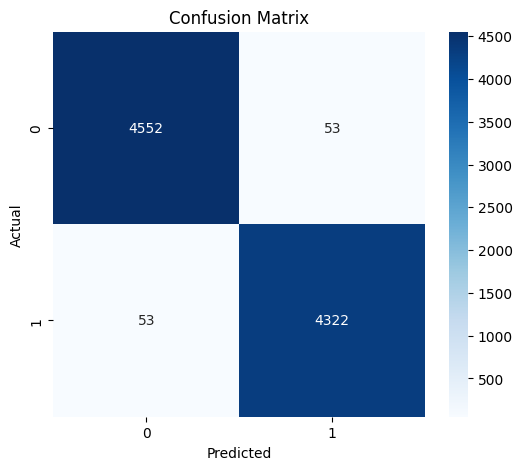

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")
plt.show()

In [23]:
def predict_news(news):

    vector = vectorizer.transform([news])

    prediction = model.predict(vector)

    if prediction[0] == 1:
        return "Real News"
    else:
        return "Fake News"

In [24]:
predict_news("U.S. will ‘bitterly regret’ attacking IRIS Dena: Iranian Foreign Minister")

'Real News'

In [27]:
predict_news("Black team Block Hurricane Rescue Efforts")

'Fake News'